# Contact Validation
## Linear Elasticity with Contact



This example describes a minimal impact problem in **2D** to validate the contact formulation.

A ball starting at a height of `h0_ball` is falling due to gravity and hits a horizontal plate.

The initial velocity of the ball is zero. The initial gap between the ball and the plate is `h_fall`.

The horizontal plate is fixed at the bottom edge in vertical direction and at the left and right edge in horizontal direction.

The wall is modeled as rigid steel plate. The ball is modeled as linear elastic and as hyperelastic Neo-Hookean material.

The contact is modeled using a **contact boundary** between the ball and the plate. It uses a coefficient function to track the distance between the two bodies.
The coefficient function is implemented in an **absolute** and **incremental** manner. If the coefficient function is evaluated positive, an energy term is added to the system equation. This energy term penalizes the penetration of the ball into the plate (see below).

The validation is based on the conservation of energy. The total energy is the sum of the kinetic energy, the potential energy due to gravity, the elastic strain energy, and the contact energy.

$$
\text{Total Energy} = \text{Kinetic Energy} + \text{Potential Energy} + \text{Elastic Strain Energy} + \text{Contact Energy}
$$

Furthermore, the average velocity of the ball after the impact is compared to the theoretical value based on the initial potential energy.

$$
v_{\text{impact}} = \sqrt{2 \cdot g \cdot h_{\text{fall}}}
$$



**Material Laws**

*a) Linear Elasticity*

- Linear strain: $\epsilon = \frac{1}{2}(\nabla u + (\nabla u)^T)$
    - Displacement field: $u$

- Linear strain energy density: $\Psi = \mu \epsilon : \epsilon + \frac{\lambda}{2} (\text{trace}(\epsilon))^2$
    - Lamé parameters: $\mu, \lambda$

*b) Hyperelasticity (Neo-Hookean)*

- Deformation gradient $\mathbf F = \mathbf I + \operatorname{Grad}\vec u$, $F_{ij} = \delta_{ij} + \partial u_i/\partial X_j$

- Right Cauchy-Green tensor $\mathbf C = \mathbf F^T \cdot \mathbf F$

-  Green strain $\mathbf E = \frac{1}{2} (\mathbf C - \mathbf I)$

- Jacobi determinant $J = \operatorname{det}\mathbf F$

- Neo-Hookean strain energy density: $\Psi = \frac{\mu}{2} (\operatorname{trace} (\mathbf C - \mathbf I)) + \frac{2\mu}{\lambda} \operatorname{det}\mathbf (C)^{-\tfrac{\lambda}{2\mu}}-1$
    - Lamé parameters: $\mu, \lambda$

**Contact Setup**

- Defines the contact boundary between the contact edges of the ball and the wall
    - Master: contact edge of the wall
    - Slave: contact edge of the ball

- `X_M`: Master surface reference coordinates (undeformed configuration)

- `X_S`: Slave surface reference coordinates (undeformed configuration)

- `n_S`: Inverted normal vector of the slave surface (points outwards from the master/wall surface)

*a) Absolute Gap*

- Computes the current positions of both surfaces by adding their total displacements to the reference positions
- Tracks the **absolute distance between surfaces in the current deformed configuration**
- Rigid contact is achieved for lower penalty parameters compared to the incremental gap formulation ($k_n \approx 10^6 \frac{N}{m}$)
- `cur_pos_master`: Current position of the **master surface**
    - `X_M`: reference position of the master surface in the undeformed configuration
    - `u`: current displacement trial function of the master surface in the deformed configuration
- `cur_pos_slave`: Current position of the **slave surface**
    - `X_S`: reference position of the slave surface in the undeformed configuration
    - `u`: current displacement trial function of the slave surface in the deformed configuration

*b) Incremental Gap*

- Used in example with three balls and one wall to handle frequently changing contact conditions
- All involved contact surfaces are defined as master and slave surfaces at the same time
    - `contact = ContactBoundary(mesh.Boundaries("contact|balls"), mesh.Boundaries("contact|balls"))`
- Computes the displacement changes since the last time step for both surfaces
- Tracks only the **incremental motion between time steps** 
- `increment_master`: Current position of the **master surface** 
    - `u_old`: displacement of the master surface at the previous time step
- `increment_slave`: Current position of the **slave surface**
    - `u_old.Other()`: displacement of the slave surface at the previous time step

*c) Gap Function*

- The gap function `cf` computes the distance between in normal direction for both formulations
- A penalty energy term `kn * cf * cf` is added that increases quadratically as penetration depth increases
- The conditional `IfPos(cf, penalty_energy, 0)` ensures that the penalty term is only active when the gap function indicates penetration (i.e., `cf` >0)
- If a nearly rigid contact is desired, the penalty parameter `k_n` must be sufficiently large to prevent significant penetration
    - *Incremental gap*: `k_n ≈ 10^11 N/m`
    - *Absolute gap*: `k_n ≈ 10^6 N/m`

*d) Example for Absolute and Incremental Gap Formulation*

- We consider the vertical motion in the y-direction of the ball into the wall
- The wall is located at y=0
- The ball has an initilal position of y=0.2m and is downward accelerated by gravity
- We consider different increasing time steps to show the effect of the two contact formulations

$$
\begin{align*}
    \text{cf}_{\text{abs}} &= \left[(X_M + u_M) - (X_S + u_S)\right] \cdot n_S \\
    \text{cf}_{\text{inc}} &= \left[(X_M + u_M - u_{old,M}) - (X_S + u_S - u_{old,S})\right] \cdot n_S
\end{align*}
$$

*Case 1: Incremental Gap Fails*
|Time Step|`X_M` [m]|`u` [m]| `u_old` [m]|`X_S` [m]| `u` [m]| `u_old` [m]| Absolute Gap [m]|Incremental Gap [m]|
|-|-|-|-|-|-|-|-|-|
|0|0|0|0|0.2|0|0|-0.2|-0.2|
|1|0|0|0|0.2|-0.1|0|-0.1|-0.1|
|2|0|0|0|0.2|-0.15|-0.1|-0.05|-0.15|
|3|0|0|0|0.2|-0.25|-0.15|+0.05|-0.1|

For the third time step, the ball penetrates the wall by 0.05 m. However, the incremental gap formulation only considers the incremental motion since the last time step. And does not see the total penetration of the wall.

The incremental gap formulation see the penetration if the time steps are larger such that it can react on the penetration.
Moreover, it might work if both surfaces are defined as master and slave surfaces at the same time (e.g. three balls and one wall example).

*Case 2: Both Formulations Work*
|Time Step|`X_M` [m]|`u` [m]| `u_old` [m]|`X_S` [m]| `u` [m]| `u_old` [m]| Absolute Gap [m]|Incremental Gap [m]|
|-|-|-|-|-|-|-|-|-|
|0|0|0|0|0.2|0|0|-0.2|-0.2|
|1|0|0|0|0.2|-0.1|0|-0.1|-0.1|
|2|0|0|0|0.2|-0.35|-0.1|+0.15|+0.05|

If the surfaces are defined one as master and the other as slave, the incremental gap formulation only works and reacts on the penetration if the incremental step between two steps is large enough such that the sign of the gap function flips.

*e) Contact Update*

- The contact is updated within each time step `contact.Update()` before solving the variational problem with `MinimizeNewton()`
- Code: `cb.Update(uold, bfmstar, intorder=5, maxdist=0.01)`
- For every facet element on the master side an integration order is created (`intorder=5`) to accurately integrate the contact contributions
- Each mapped master point in the deformed configuration queries the searchtree for nearby slave elements wihin 
- For each candidates slave element, it computes the closest point on the slave element 

**Imports**

In [45]:
import numpy as np
import matplotlib.pyplot as plt

from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *
from ngsolve.solvers import NewtonMinimization
from netgen.webgui import Draw as DrawGeo

**Geometry and Mesh**

In [74]:
# Parameters and constants
r_ball = 0.1
h_fall = 0.01
initial_y_velocity = 0.0
g = 9.81

v_max_th = np.sqrt(2*g*(h_fall))

maxh = r_ball / 5
mesh_order = 3

# Symmetry flag
use_symmetry = False

# Geometry parameters
rect_len_x = 3 * r_ball
rect_len_y = r_ball / 4
h0_ball = rect_len_y + r_ball + h_fall

# Define wall geometry
wall = MoveTo(-rect_len_x/2, 0).Rectangle(rect_len_x, rect_len_y).Face()
wall.edges.Max(Y).maxh = r_ball/20
wall.edges.Max(Y).name = "contact_wall"
wall.edges.Min(Y).name = "fix_y"
wall.edges.Max(X).name = "fix_x"
wall.edges.Min(X).name = "fix_x"
wall.name = "wall"

# Define ball geometry
ball = Circle((0, h0_ball), r_ball).Face()
ball.edges.Max(Y).maxh = r_ball/20
ball.edges.name = "contact_ball"
ball.name = "ball"

if use_symmetry:
    # Cut at y=0 for symmetry
    sym_cut = MoveTo(-rect_len_x/2,0).Rectangle(rect_len_x/2, rect_len_y + h0_ball + r_ball).Face()
    sym_cut.edges.Max(X).name = "sym"

    wall = wall - sym_cut
    ball = ball - sym_cut

geo = Compound([ball, wall])
geo = OCCGeometry(geo, dim = 2)

mesh = Mesh(geo.GenerateMesh(maxh=maxh, quad_dominated=False))
mesh.Curve(mesh_order)

Draw(mesh)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

**Material Parameters**

In [75]:
# Rigid steel material for wall
E_wall, nu_wall = 210e9, 0.2
rho_wall = 7850
thickness = 1
mu_wall  = E_wall / 2 / (1+nu_wall)
lam_wall = E_wall * nu_wall / ((1+nu_wall)*(1-2*nu_wall))

In [76]:
# Linear Elasticity
def eps(u):
    return Sym(Grad(u))

def linear_elastic_strain_energy_density(eps, lam, mu):
    return 0.5*lam*Trace(eps)**2 + mu*InnerProduct(eps, eps)

def stress_hooke(eps, lam, mu):
    sigma = 2 * mu * eps + lam * Trace(eps) * Id(mesh.dim)
    return sigma

# Neo-Hookean
def C(u):
    F = Id(mesh.dim) + Grad(u)
    return F.trans * F

def neo_hookean (C, lam, mu):
    return 0.5*mu*(Trace(C-Id(mesh.dim)) + 2*mu/lam*Det(C)**(-lam/2/mu)-1)

def stress_neo_hookean(C, lam, mu):
    return 0.5 * mu * (Id(mesh.dim) - Det(C) ** (-lam / 2 / mu) * Inv(C))    

# Energy densities
def gravitational_energy_density(u, rho):
    # y_current = y + u_y
    return rho * g * (y + u[1])

def kinetic_energy_density(v_mid, rho):
    return 0.5 * rho * InnerProduct(v_mid, v_mid)

In [99]:
def run_test_case(config):
    # Material parameters
    E = config['E']
    nu = config['nu']
    rho = config['rho']
    material_law = config['material_law']
    gap_type = config['gap_type']
    kn = config['kn']

    mu  = E / 2 / (1+nu)
    lam = E * nu / ((1+nu)*(1-2*nu))
    
    # Select material law
    strain_energy_density = None
    deformation_gradient  = None

    if material_law == "linear_elastic":
        strain_energy_density = linear_elastic_strain_energy_density
        deformation_gradient  = eps
        stress = stress_hooke

    elif material_law == "neo_hookean":
        strain_energy_density = neo_hookean
        deformation_gradient  = C
        stress = stress_neo_hookean
    
    # Time stepping parameters
    tau  = 5e-4
    t    = 0
    tend = 0.2
    
    # Finite Element Space and Grid Functions
    fes = VectorH1(mesh, order=mesh_order, dirichletx="fix_x|sym", dirichlety="fix_y")
    fes_stress = MatrixValued(H1(mesh, order=mesh_order, definedon=mesh.Materials("ball")))
    u, v = fes.TnT()

    u_old = GridFunction(fes)
    u_new = GridFunction(fes)

    v_old = GridFunction(fes)
    v_new = GridFunction(fes)

    a_new = GridFunction(fes)
    a_old = GridFunction(fes)
    
    stress = GridFunction(fes_stress)

    u_history = GridFunction(fes, multidim=0)
    v_history = GridFunction(fes, multidim=0)
    a_history = GridFunction(fes, multidim=0)
    
    stress_history = GridFunction(fes_stress, multidim=0)
    
    #Setup initial velocity and acceleration
    u_new.Set( (0, initial_y_velocity) )
    v_new.Set( (0,0) )
    
    #-------------------------------------------------------
    # Bilinear form
    bfmstar = BilinearForm(fes)
    
    # Add strain energy term wall (always linear elastic)
    bfmstar += Variation( linear_elastic_strain_energy_density(eps(u), lam_wall, mu_wall).Compile(False) * dx("wall") )
    
    # Add strain energy term ball
    bfmstar += Variation( strain_energy_density(deformation_gradient(u), lam, mu).Compile(False) * dx("ball") )

    # Define gravitational force
    force = CF((0,-g*rho*thickness))

    # Add gravitational force term
    bfmstar += Variation( -force * 0.5*(u + u_old) * dx("ball") )

    # Add inertial term (Newmark method)
    bfmstar += Variation( rho/2 * 2/tau**2 * (u - u_old - tau*v_new -tau**2/4*a_old)**2 * dx("ball") )
    
    #-------------------------------------------------------
    # Contact Definition
    master = mesh.Boundaries("contact_wall")
    slave = mesh.Boundaries("contact_ball")
    contact = ContactBoundary(master, slave)

    X_M = CoefficientFunction((x,y))
    X_S = X_M.Other()
    n_S = -specialcf.normal(2).Other()
    
    if gap_type == "absolute":
        cur_pos_master = X_M + u
        cur_pos_slave = X_S + u.Other()
        cf = (cur_pos_master - cur_pos_slave) * n_S
    
    elif gap_type == "incremental":
        increment_master = X_M + u - u_old
        increment_slave = X_S + u.Other() - u_old.Other()
        cf = (increment_master - increment_slave) * n_S
    
    penalty_energy = kn * cf * cf
    contact.AddEnergy(IfPos(cf, penalty_energy, 0), deformed = True)
    
    #-------------------------------------------------------
    # Analytical total energy
    area_ball = Integrate(1, mesh, definedon=mesh.Materials("ball"))
    E_tot_analytical = rho * g * area_ball * (h0_ball)

    # History Lists
    time_hist   = []
    E_kin_hist  = []
    E_grav_hist = []
    E_ela_hist  = []
    E_con_hist  = []
    E_tot_hist  = []
    vy_cm_hist  = []
    
    # Visualization
    #scene_u = Draw (u_new, mesh, "disp", deformation=u_new)   
    scene_sig = Draw (Norm(stress), mesh, "stress", deformation=u_new, colormap="jet")
    
    #-------------------------------------------------------
    # Simulation loop
    i = 0
    with TaskManager():
        while t < tend:
            t += tau
            
            # Time step update
            u_old.vec.data = u_new.vec
            v_old.vec.data = v_new.vec
            a_old.vec.data = a_new.vec

            # Update contact and solve for new displacement
            contact.Update(u_old, bfmstar, 5, 0.01)
            NewtonMinimization (a=bfmstar, u=u_new, printing=False, inverse="sparsecholesky")
            
            # Update acceleration and velocity (Newmark)
            a_new.vec.data  = u_new.vec - u_old.vec - tau*v_new.vec - (tau**2/4)*a_old.vec
            a_new.vec.data *= 4/tau**2
            v_new.vec.data += 0.5*tau*a_old.vec
            v_new.vec.data += 0.5*tau*a_new.vec
            
            # Update stress
            if material_law == "linear_elastic":
                stress.Interpolate(stress_hooke(eps(u_new), lam, mu))
            elif material_law == "neo_hookean":
                stress.Interpolate(stress_neo_hookean(C(u_new), lam, mu))
                
            # Only norm of stress
            #stress.Set(Norm(stress))
            
            # Store history
            u_history.AddMultiDimComponent(u_new.vec)
            v_history.AddMultiDimComponent(v_new.vec)
            a_history.AddMultiDimComponent(a_new.vec)
            stress_history.AddMultiDimComponent(stress.vec)
            
            # Mid point velocity
            u_mid = 0.5 * (u_old + u_new)
            v_mid = 0.5 * (v_old + v_new)
            
            # Energies
            E_kin       = Integrate( kinetic_energy_density(v_mid, rho), mesh, definedon=mesh.Materials("ball"))
            E_grav      = Integrate( gravitational_energy_density(u_mid, rho), mesh, definedon=mesh.Materials("ball") )
            E_ela_ball  = Integrate( strain_energy_density(deformation_gradient(u_new), lam, mu), mesh, definedon=mesh.Materials("ball") )
            E_ela_wall  = Integrate( linear_elastic_strain_energy_density(eps(u_new), lam_wall, mu_wall), mesh, definedon=mesh.Materials("wall") )
            E_ela       = E_ela_ball + E_ela_wall
            
            E_tot  = E_kin + E_ela + E_grav
            E_con  = E_tot_analytical - E_tot
            
            #E_contact = Integrate(IfPos(cf, kn*cf*cf, 0), mesh, definedon=mesh.Boundaries("contact_ball"))
            #rel_error = abs(E_tot - E_tot_analytical) / abs(E_tot_analytical) * 100
            vy_avg = Integrate(v_new[1], mesh, definedon=mesh.Materials("ball")) / area_ball
            vy_cm_hist.append(vy_avg)
            
            time_hist.append(t)
            E_kin_hist.append(E_kin)
            E_ela_hist.append(E_ela)
            E_grav_hist.append(E_grav)
            E_tot_hist.append(E_tot)
            E_con_hist.append(E_con)    
            
            if i % 50 == 0:
                print(f"t: {t:.4f} / {tend:.4f}")
            i += 1

            #scene_u.Redraw()
            scene_sig.Redraw()
    
    return {
        "time": time_hist,
        "E_kin": E_kin_hist,
        "E_ela": E_ela_hist,
        "E_grav": E_grav_hist,
        "E_tot": E_tot_hist,
        "E_con": E_con_hist,
        "vy_cm": vy_cm_hist,
        "u_history": u_history,
        "sigma_history": stress_history
    }

In [104]:
settings = {"Multidim": {
                    "speed" : 30
                }}

def animate(u_hist, settings=settings):

    Draw(u_hist, mesh,
         interpolation_multidim=True,
         deformation = u_hist,
         animate = True,
         autoscale=True,
         settings = settings
    )

### Test Cases: Linear Elasticity

In [105]:
config_1 = {'E': 210e9,
            'nu': 0.3,
            'rho': 7850,
            'material_law': 'linear_elastic', 
            'gap_type': 'incremental',
            'kn': 1e11}

res_config_1 = run_test_case(config_1)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

t: 0.0005 / 0.2000


KeyboardInterrupt: 

In [107]:
sig_hist = res_config_1['sigma_history']
u_hist = res_config_1['u_history']
animate(u_hist)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 30}}, …

In [29]:
sigma_history = res_config_1['sigma_history']

Draw(sigma_history, mesh,
        interpolation_multidim=True,
        colormap="jet",
        settings = {"Multidim": {"speed" : 30}})


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 30}}, …

BaseWebGuiScene

In [58]:
config_2 = {'E': 210e9,
            'nu': 0.3,
            'rho': 7850,
            'material_law': 'linear_elastic', 
            'gap_type': 'incremental',
            'kn': 1e9}

res_config_2 = run_test_case(config_2)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

t: 0.0005 / 0.2000
t: 0.0255 / 0.2000
t: 0.0505 / 0.2000
t: 0.0755 / 0.2000
t: 0.1005 / 0.2000
t: 0.1255 / 0.2000
t: 0.1505 / 0.2000
t: 0.1755 / 0.2000


In [112]:
animate(res_config_2['u_history'])

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 30}}, …

In [59]:
config_3 = {'E': 210e9,
            'nu': 0.3,
            'rho': 7850,
            'material_law': 'linear_elastic', 
            'gap_type': 'absolute',
            'kn': 1e6}

res_config_3 = run_test_case(config_3)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

t: 0.0005 / 0.2000
t: 0.0255 / 0.2000
t: 0.0505 / 0.2000
t: 0.0755 / 0.2000
t: 0.1005 / 0.2000
t: 0.1255 / 0.2000
t: 0.1505 / 0.2000
t: 0.1755 / 0.2000


In [60]:
config_4 = {'E': 210e9,
            'nu': 0.3,
            'rho': 7850,
            'material_law': 'linear_elastic', 
            'gap_type': 'absolute',
            'kn': 1e7}

res_config_4 = run_test_case(config_4)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

t: 0.0005 / 0.2000
t: 0.0255 / 0.2000
t: 0.0505 / 0.2000
t: 0.0755 / 0.2000
t: 0.1005 / 0.2000
t: 0.1255 / 0.2000
t: 0.1505 / 0.2000
t: 0.1755 / 0.2000


In [65]:
configs_1 = [config_1, config_2, config_3, config_4]
results_1 = [res_config_1, res_config_2, res_config_3, res_config_4]

times_1   = [np.array(res["time"]) for res in results_1]
E_kins_1  = [np.array(res["E_kin"]) for res in results_1]
E_elas_1  = [np.array(res["E_ela"])for res in results_1]
E_gravs_1 = [np.array(res["E_grav"]) for res in results_1]
E_tots_1  = [np.array(res["E_tot"]) for res in results_1]
E_cons_1  = [np.array(res["E_con"]) for res in results_1]
vy_cms_1  = [np.array(res["vy_cm"]) for res in results_1]

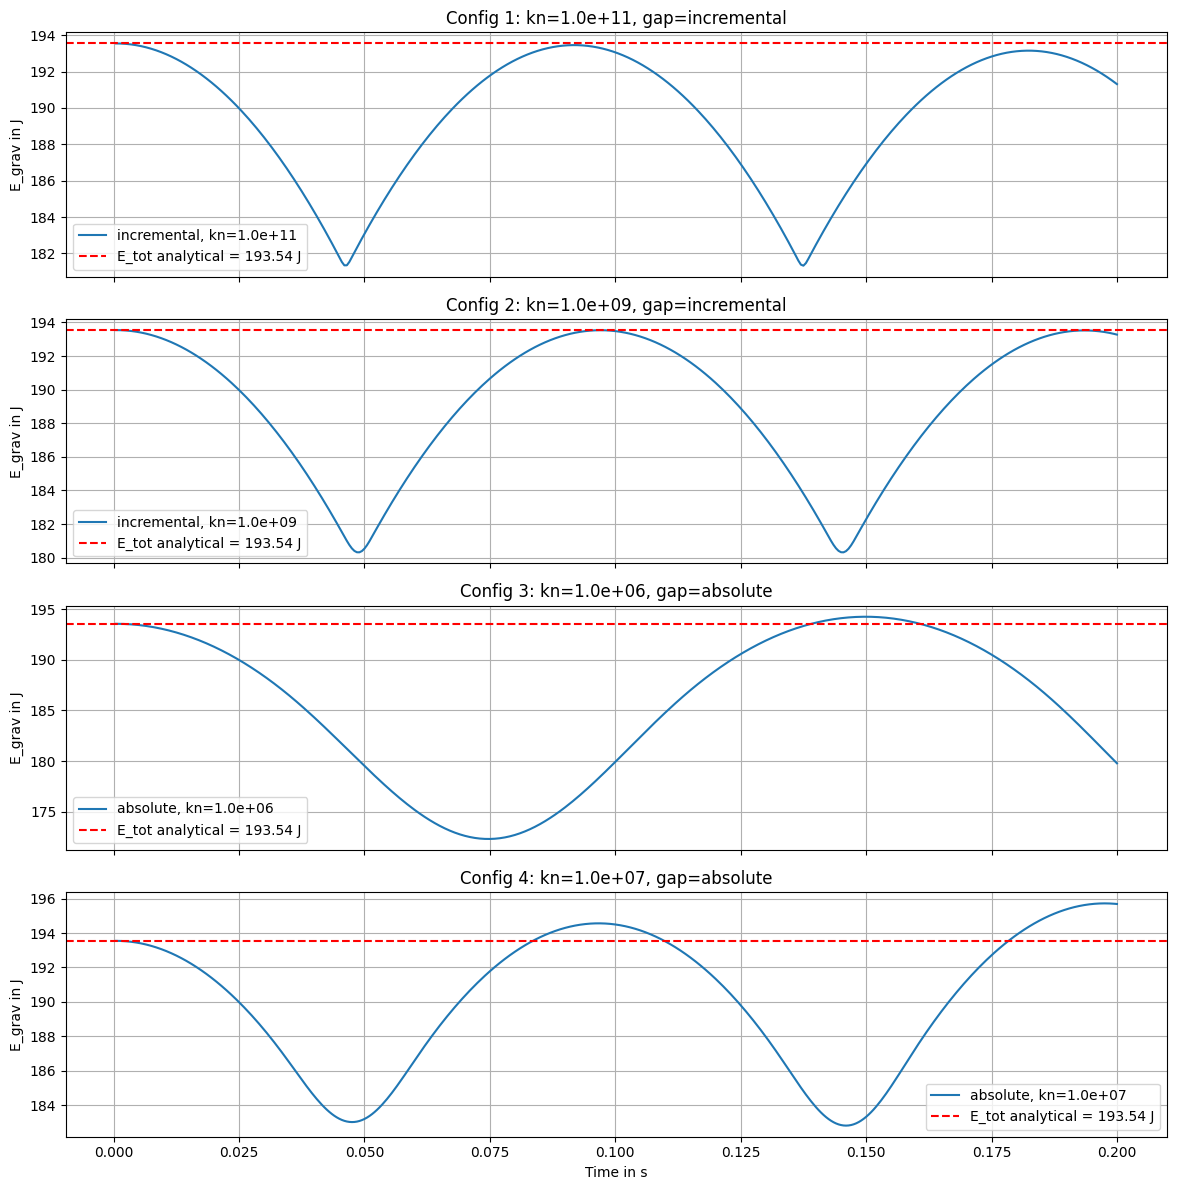

In [106]:
# Calculate Relative energy error for the different configurations
rho = config_1['rho']
A_ball = Integrate(1, mesh, definedon=mesh.Materials("ball"))
E_tot_th = rho * g * A_ball * thickness * (h0_ball)

# Plot gravitational energies for all linear elastic cases
fig, axs = plt.subplots(len(E_gravs_1), 1, figsize=(12, 3*len(E_gravs_1)), sharex=True)
for i, E_grav in enumerate(E_gravs_1):
    axs[i].plot(times_1[i], E_grav, label=f'{configs_1[i]["gap_type"]}, kn={configs_1[i]["kn"]:.1e}')
    axs[i].axhline(E_tot_th, color='r', linestyle='--', label=f'E_tot analytical = {E_tot_th:.2f} J')
    axs[i].set_ylabel('E_grav in J')
    axs[i].set_title(f'Config {i+1}: kn={configs_1[i]["kn"]:.1e}, gap={configs_1[i]["gap_type"]}')
    axs[i].legend()
    axs[i].grid()
axs[-1].set_xlabel('Time in s')
plt.tight_layout()
plt.show()

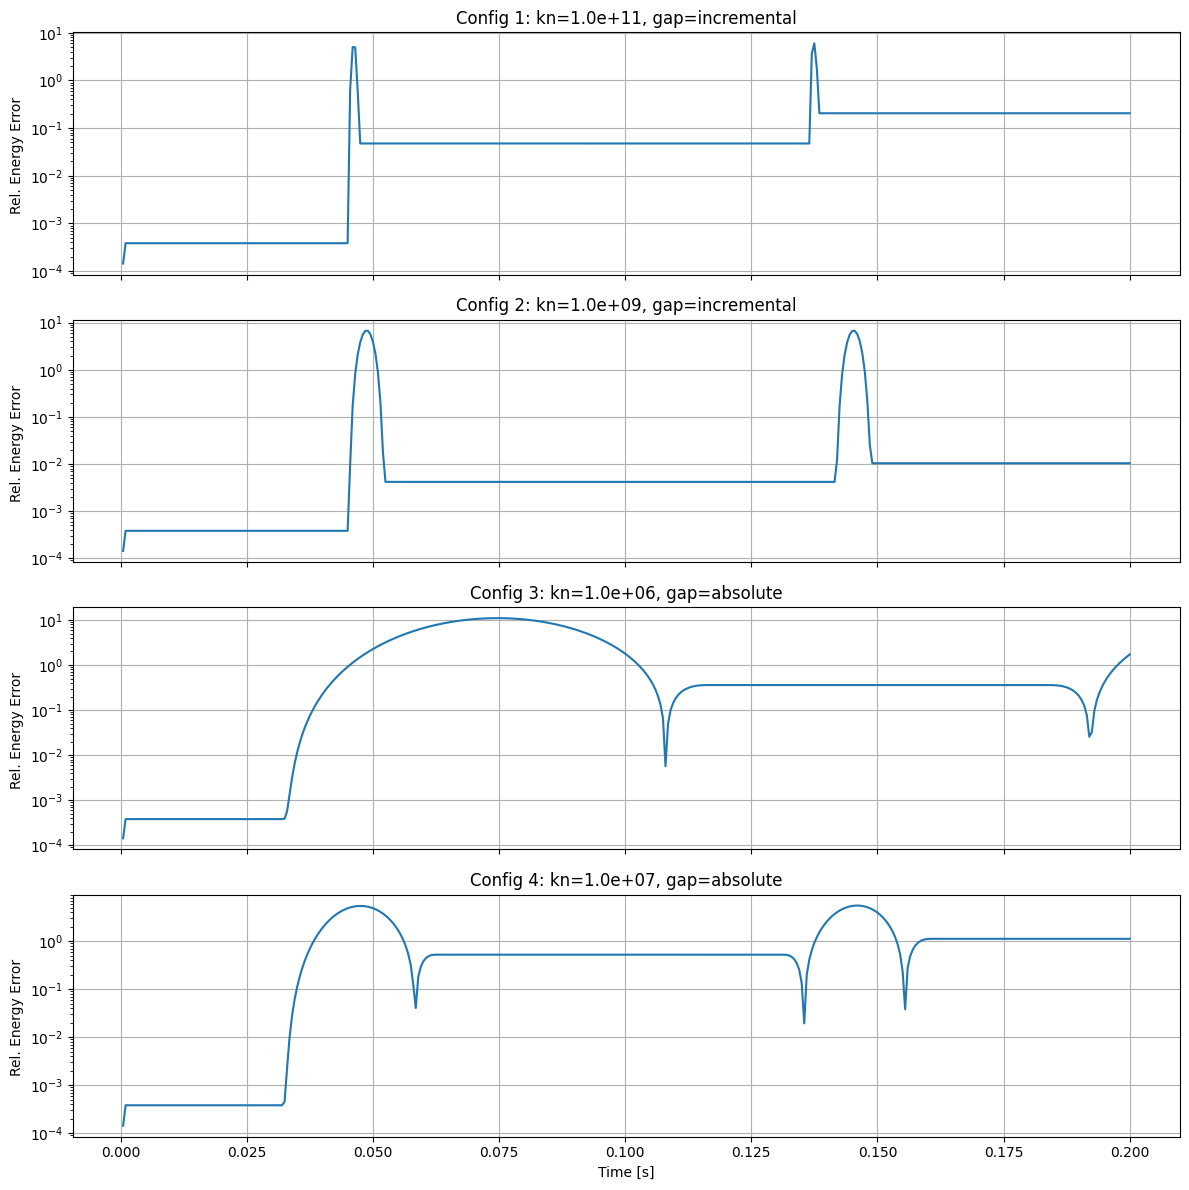

In [105]:
rel_errors_1 = [abs(E_tot - E_tot_th) / abs(E_tot_th) for E_tot in E_tots_1]

# Plotting
fig, axs = plt.subplots(len(rel_errors_1), 1, figsize=(12, 3*len(rel_errors_1)), sharex=True)
for i, rel_error in enumerate(rel_errors_1):
    axs[i].semilogy(times_1[i], np.array(rel_error)*100)
    axs[i].set_ylabel('Rel. Energy Error ')
    axs[i].set_title(f'Config {i+1}: kn={configs_1[i]["kn"]:.1e}, gap={configs_1[i]["gap_type"]}')
    axs[i].grid()
axs[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()



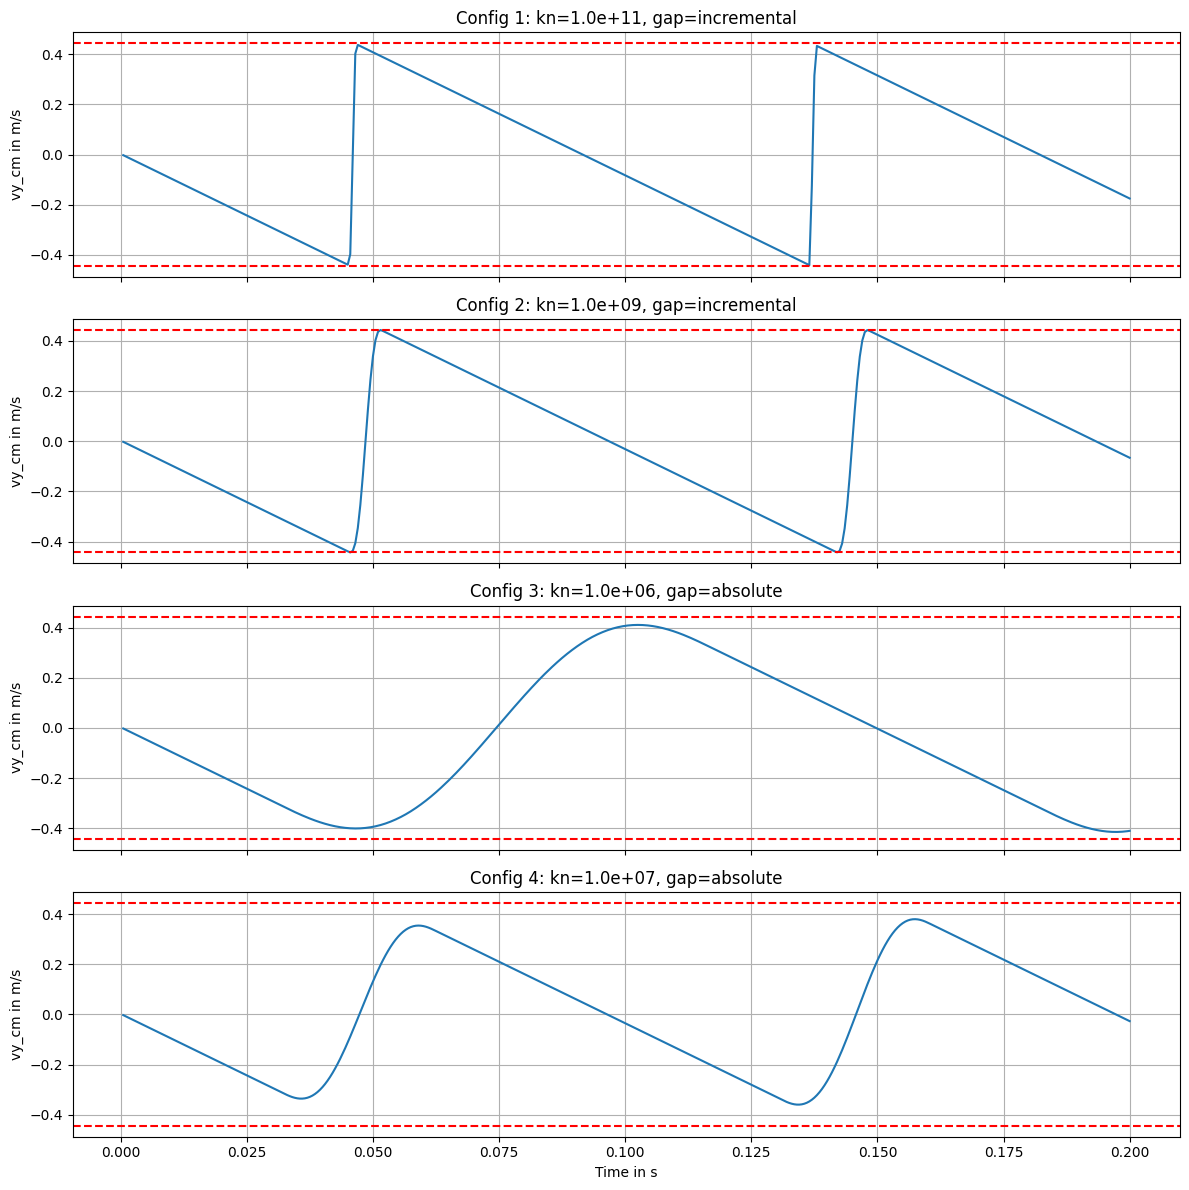

In [ ]:
# Plot all vy_cm for the different configurations
fig, axs = plt.subplots(len(vy_cms_1), 1, figsize=(12, 3*len(vy_cms_1)), sharex=True)
fig.suptitle('Linear Elastic Material: Vertical Ball Velocity', fontsize=16, y=1.02, fontweight='bold')
for i, vy_cm in enumerate(vy_cms_1):
    axs[i].plot(times_1[i], vy_cm, label=f'{configs_1[i]["gap_type"]}, kn={configs_1[i]["kn"]:.1e}')
    axs[i].axhline(v_max_th, color='r', linestyle='--', label='v_max theoretical')
    axs[i].axhline(-v_max_th, color='r', linestyle='--')
    axs[i].set_ylim(-1.1*v_max_th, 1.1*v_max_th)
    axs[i].set_ylabel('vy_cm in m/s')
    axs[i].set_title(f'Config {i+1}: kn={configs_1[i]["kn"]:.1e}, gap={configs_1[i]["gap_type"]}')
    axs[i].grid()
axs[-1].set_xlabel('Time in s')
plt.tight_layout()
plt.show()

### Test Case 2: Hyperelasticity (Neo-Hookean)

In [108]:
config_5 = {'E': 5e4,
            'nu': 0.45,
            'rho': 1000,
            'material_law': 'neo_hookean',
            'gap_type': 'incremental',
            'kn': 1e7}

res_config_5 = run_test_case(config_5)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

t: 0.0005 / 0.2000
t: 0.0255 / 0.2000
t: 0.0505 / 0.2000
t: 0.0755 / 0.2000
t: 0.1005 / 0.2000
t: 0.1255 / 0.2000
t: 0.1505 / 0.2000
t: 0.1755 / 0.2000


In [13]:
vtk = VTKOutput(mesh, coefs=[res_config_5["u_history"]], names=["displacement"], filename="contact_neo_hookean")
vtk.Do()

'contact_neo_hookean'

In [33]:
u_hist_c5 = res_config_5["u_history"]

ani_settings = {"Multidim": {
                    "speed" : 30
                }}

Draw(u_hist_c5, mesh,
     interpolation_multidim=True,
     deformation = u_hist_c5,
     animate = True,
     autoscale=False,
     min = 0, max=h_fall * 1.5,
     settings = ani_settings)

stress_hist_c5 = res_config_5['sigma_history']

Draw(stress_hist_c5, mesh,
        interpolation_multidim=True,
        colormap="jet",
        animate = True,
        settings = {"Multidim": {"speed" : 30}})

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 30}}, …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 30}}, …

BaseWebGuiScene

In [87]:
config_6 = {'E': 5e4,
            'nu': 0.45,
            'rho': 1000,
            'material_law': 'neo_hookean',
            'gap_type': 'incremental',
            'kn': 1e6}

res_config_6 = run_test_case(config_6)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

t: 0.0005 / 0.2000
t: 0.0255 / 0.2000
t: 0.0505 / 0.2000
t: 0.0755 / 0.2000
t: 0.1005 / 0.2000
t: 0.1255 / 0.2000
t: 0.1505 / 0.2000
t: 0.1755 / 0.2000


In [ ]:
config_7 = {'E': 5e4,
            'nu': 0.45,
            'rho': 1000,
            'material_law': 'neo_hookean',
            'gap_type': 'absolute',
            'kn': 1e5}

res_config_7 = run_test_case(config_7)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

t: 0.0005 / 0.2000
t: 0.0255 / 0.2000
t: 0.0505 / 0.2000
t: 0.0755 / 0.2000
t: 0.1005 / 0.2000
t: 0.1255 / 0.2000
t: 0.1505 / 0.2000
t: 0.1755 / 0.2000


In [97]:
configs_2 = [config_5, config_6, config_7]
results_2 = [res_config_5, res_config_6, res_config_7]

times_2   = [np.array(res["time"]) for res in results_2]
E_kins_2  = [np.array(res["E_kin"]) for res in results_2]
E_elas_2  = [np.array(res["E_ela"])for res in results_2]
E_gravs_2 = [np.array(res["E_grav"]) for res in results_2]
E_tots_2  = [np.array(res["E_tot"]) for res in results_2]
E_cons_2  = [np.array(res["E_con"]) for res in results_2]
vy_cms_2  = [np.array(res["vy_cm"]) for res in results_2]

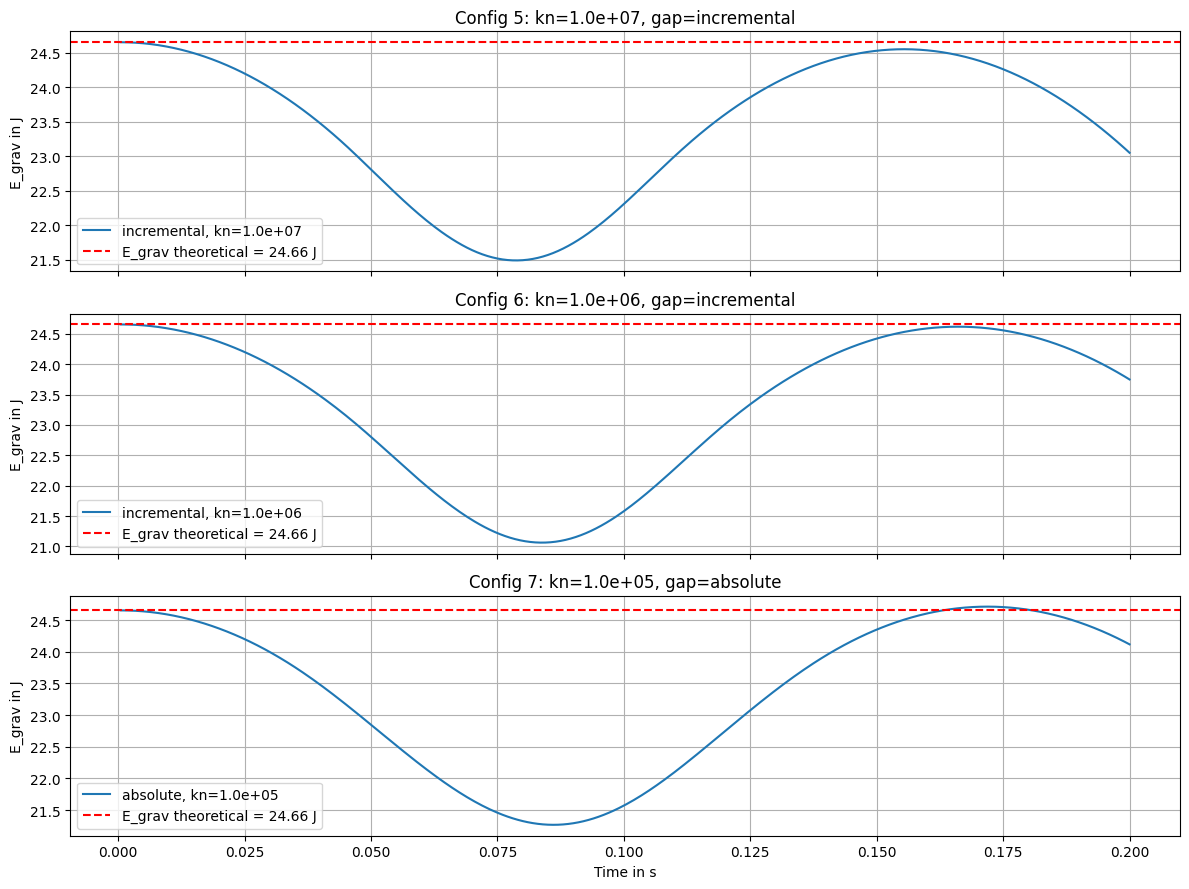

In [103]:
# Plot gravitational energies for neo-hookean cases
E_pot_th = config_5['rho'] * g * Integrate(1, mesh, definedon=mesh.Materials("ball")) * (h0_ball)

fig, axs = plt.subplots(len(E_gravs_2), 1, figsize=(12, 3*len(E_gravs_2)), sharex=True)
for i, E_grav in enumerate(E_gravs_2):
    axs[i].plot(times_2[i], E_grav, label=f'{configs_2[i]["gap_type"]}, kn={configs_2[i]["kn"]:.1e}')
    axs[i].axhline(E_pot_th, color='r', linestyle='--', label=f'E_grav theoretical = {E_pot_th:.2f} J')
    axs[i].set_ylabel('E_grav in J')
    axs[i].set_title(f'Config {i+5}: kn={configs_2[i]["kn"]:.1e}, gap={configs_2[i]["gap_type"]}')
    axs[i].grid()
    axs[i].legend()
axs[-1].set_xlabel('Time in s')
plt.tight_layout()
plt.show()

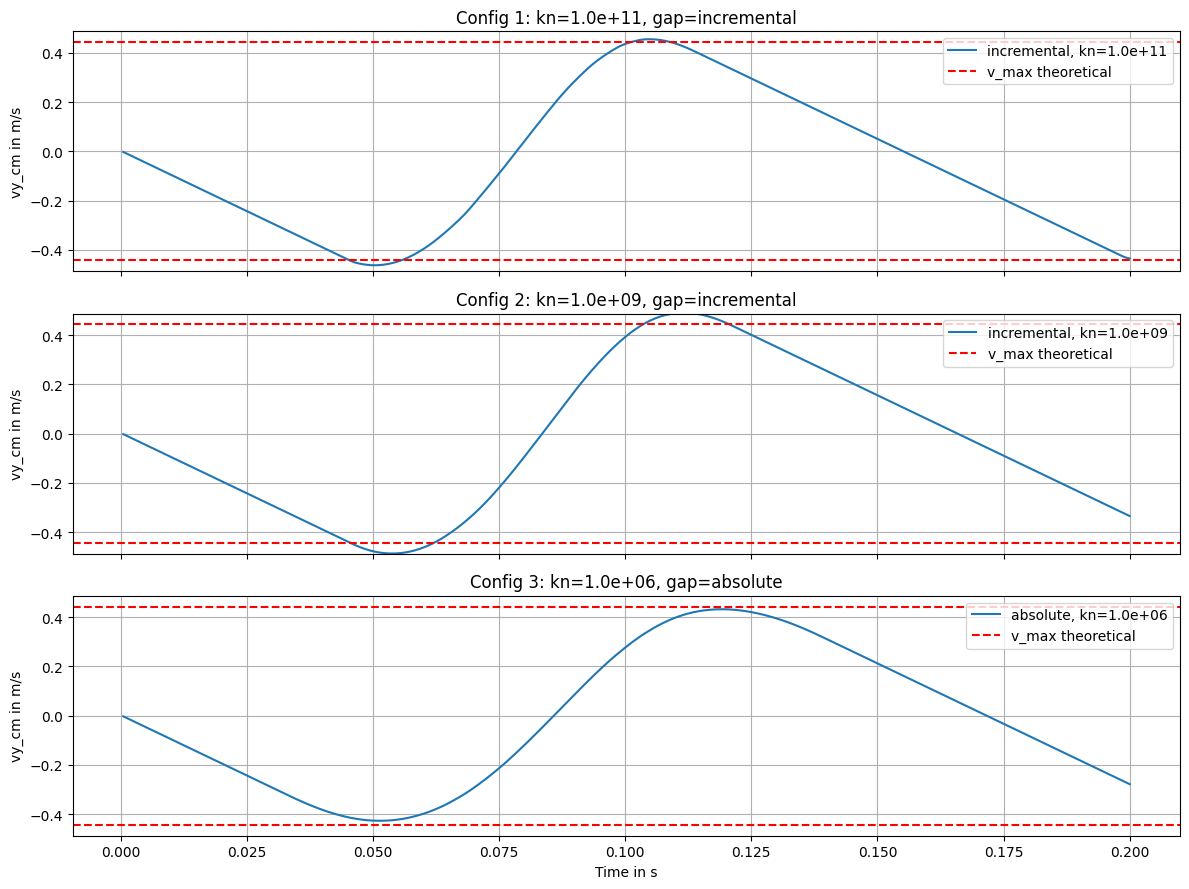

In [102]:
# Plot all vy_cm for the different configurations
fig, axs = plt.subplots(len(vy_cms_2), 1, figsize=(12, 3*len(vy_cms_2)), sharex=True)
for i, vy_cm in enumerate(vy_cms_2):
    axs[i].plot(times_1[i], vy_cm, label=f'{configs_1[i]["gap_type"]}, kn={configs_1[i]["kn"]:.1e}')
    axs[i].axhline(v_max_th, color='r', linestyle='--', label='v_max theoretical')
    axs[i].axhline(-v_max_th, color='r', linestyle='--')
    axs[i].set_ylim(-1.1*v_max_th, 1.1*v_max_th)
    axs[i].set_ylabel('vy_cm in m/s')
    axs[i].set_title(f'Config {i+1}: kn={configs_1[i]["kn"]:.1e}, gap={configs_1[i]["gap_type"]}')
    axs[i].legend()
    axs[i].grid()
axs[-1].set_xlabel('Time in s')
plt.tight_layout()
plt.show()